# Signal Anomaly Detection - Time Series Classification Pipeline

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.datasets import load_iris
import scipy.stats as stats

In [7]:
#1.

#load data
ecg = pd.read_csv("/Users/amantlesegaiso/Desktop/ecg_curated.csv", header = None)
print(ecg.shape)

# check the last  column
print(ecg[140].value_counts())

# see that theres more normal than abnormal time series signals
# the ML model might flag a lot of abnormal as normal due to a high number of them in the trainign set
# technical term for this is *Class Imbalannce*

# some signals use fewer than 140 timestamps so pandas will fill them as NaN(Not a Number), 0 implies the signal has flatlined
print(ecg.isnull().sum().sum())

(4999, 141)
140
1.0    1825
0.0     771
Name: count, dtype: int64
4108


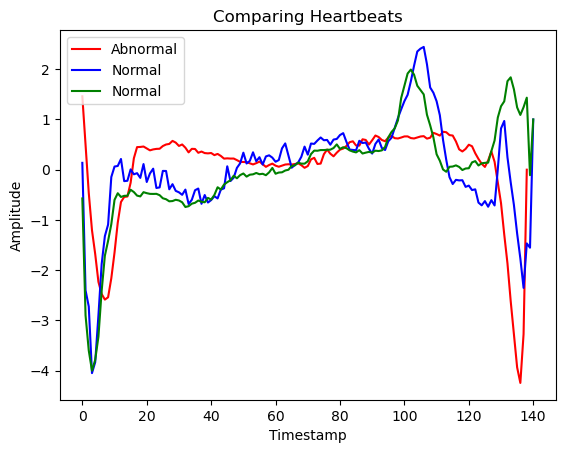

In [8]:
# plotting 2-3 example time-series signlas on the same chart

# making a function that collects 3 heartbeats, labels them as either abnormal or normal then plots a chart

def compare_heartbeats(hb1, hb2, hb3):
    # loop to check which is abnormal and abnormal
    heartbeats = [hb1, hb2, hb3]
    state1 = "Normal" if hb1[140] == 1 else "Abnormal"
    state2 = "Normal" if hb2[140] == 1 else "Abnormal"
    state3 = "Normal" if hb3[140] == 1 else "Abnormal"

    # Plotting the heartbeats
    plt.plot(hb1, "-r", label = state1)
    plt.plot(hb2, "-b", label = state2)
    plt.plot(hb3, "-g", label = state3)
    plt.legend(loc="upper left")
    plt.title("Comparing Heartbeats")
    plt.xlabel("Timestamp")
    plt.ylabel("Amplitude")
    plt.show()

# get 3 heartbeats (excluding the classification column)
compare_heartbeats(ecg.iloc[824], ecg.iloc[750], ecg.iloc[4008])

# it is clear that abnormal has different amplitude that doesnt match the path of the normal ones, sometimes having high peaks or deep lows

In [9]:
# getting a list of all the currently labelled abnorma
abnormals = []
for h in range(len(ecg)):
    if ecg.iloc[h, 140] == 1:
        state = "normal"
    else:
       state = "abmormal"
       abnormals.append(h)
# print(abnormals)

# checking how many rows are unclassified
print(ecg[140].unique())
print(ecg[140].isna().sum())

# dropping the unclassified rows
ecg_clean = ecg.dropna(subset=[140])
print(ecg_clean.shape)
print(ecg_clean[140].value_counts())


[nan  1.  0.]
2403
(2596, 141)
140
1.0    1825
0.0     771
Name: count, dtype: int64


140    2596
Name: count, dtype: int64


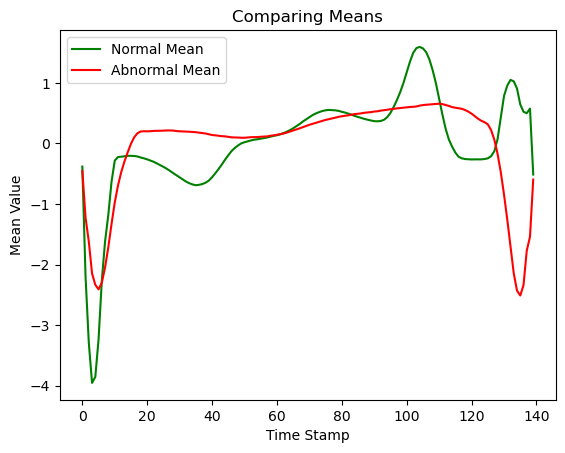

In [10]:
# count non-null values per row and plot a histogram separated by class
ecg_clean.isnull().sum().sum()
#ecg.notnull().sum()
signal_lengths = ecg_clean.iloc[:, :140].notna().sum(axis=1)
print(signal_lengths.value_counts())

# statistics, mean, std, min, max
ecg_clean.iloc[:, :140].describe()

normal = ecg_clean.loc[ecg_clean[140] == 1]
abnormal = ecg_clean.loc[ecg_clean[140] == 0]
normal_mean = normal.iloc[:, :140].mean()
abnormal_mean = abnormal.iloc[:, :140].mean()
plt.plot(normal_mean, "-g", label = "Normal Mean")
plt.plot(abnormal_mean, "-r", label = "Abnormal Mean")
plt.legend(loc="upper left")
plt.title("Comparing Means")
plt.xlabel("Time Stamp")
plt.ylabel("Mean Value")
plt.show()

## 1. Data Understanding & Exploration
- 2596 usable labeled instances after dropping 2403 unlabeled rows
- 140 signal features, 1 target column
- Class imbalance: 1825 normal vs 771 abnormal (2:1 ratio)
- 4108 NaN values in signal columns indicating variable length
- Visual inspection shows abnormal heartbeats have irregular amplitued patterns including deep negative spikes
- the unlabeled rows and the variable-length signals appear to overlap significantly
- signal amplitudes range from 7 to 8, std between 0 and 2
- normal mean signal shows deeper initial dip, more oscillations and higher peaks towards the end
- abnormal mean signal is reletively flat after the intitial dip, with a notable dip near the end
- most discrimination differences between classes appear at the start and end of the signal 


In [11]:

# Building the ABT(Analytic Base Table) with at least 5 columns
# function that takes a single row and returns the 5 feature values, and apply it to the whole ecg_clean dataframe

def compute_static_profile(heartbeat):
    q1 = heartbeat[0:40]
    q2 = heartbeat[40:100]
    q3 = heartbeat[100:140]
    qA = heartbeat[0:140]
    min_val = np.min(qA)
    mean_val = np.mean(qA)
    max_val = np.max(qA)
    std_q1 = np.std(q1)
    std_q2 = np.std(q2)
    std_q3 = np.std(q3)
    range_val = max_val - min_val
    return [mean_val, std_q1, std_q2, std_q3, range_val]
ecg_clean.apply(compute_static_profile, axis=1)
# saving the result
ABT = pd.DataFrame(
    ecg_clean.apply(compute_static_profile, axis=1).tolist(),
    columns=['mean', 'std_early', 'std_mid', 'std_late', 'range']
)
ABT['target'] = ecg_clean[140].values
print(ABT.head())
print(ABT.shape)

           mean  std_early   std_mid  std_late     range  target
0  4.857143e-10   1.082952  0.355409  0.757457  6.419527     1.0
1  2.214285e-10   1.098532  0.399318  0.909046  6.226432     1.0
2  3.285715e-10   1.035729  0.392109  0.912026  6.586989     1.0
3 -1.750000e-09   0.722574  0.092839  1.608004  5.914119     0.0
4 -6.571429e-10   1.127855  0.366441  0.948156  6.516884     1.0
(2596, 6)


## 2. Feature Engineering
##### When looking at the graph comparing means, -the most noticeable differances were shown in:
- the beginning and last third of the profile
- ranges of the amplitudes
- The mean of a time-series signal also plays a role


<Axes: >

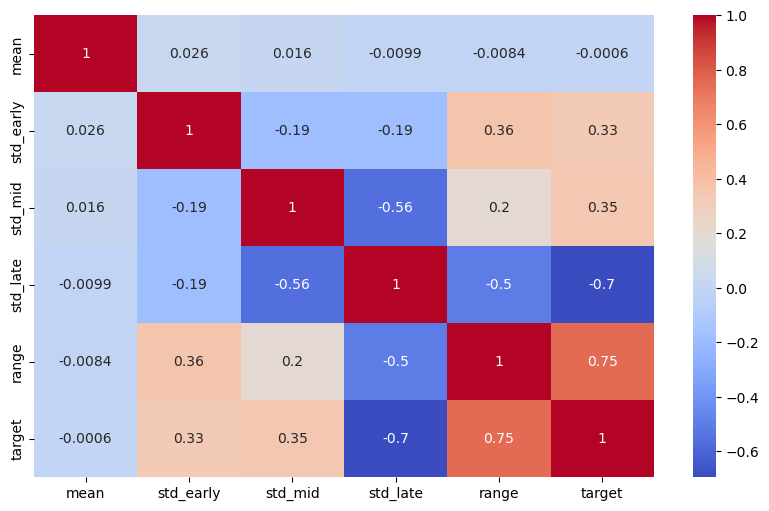

In [12]:

# parwise correlations between ABT features and target variable
corr = ABT.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True, cmap='coolwarm')

## 3. Correlation Analysis
- Range and std_late are the strongest predictors - decision tree will likely priorities these for splits
- mean is essentially usesless for classification, the tree may ignore it entierly
- moderate correlations between some features(range and std_early at 0.36) means mild multicollinearity
- random forest is less affected by multicollinearity than a single decision tree

In [13]:
# Task -4 
# extracting 3 components from ABT independent variables and applying PCA
X = ABT.iloc[:, :5]
y = ABT.iloc[:, 5]

scaler = StandardScaler() #standardizing
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)



[0.38343031 0.25336742 0.20024201]


## 4. Dimensionality Reduction (PCA)
##### Benefits of of PCA for this specific use case:
 1. Dimensionality reduction - simpler, faster models
 2. Removes multicollinearity between features
 3. reduces overfitting for Decision Trees
##### PC1, PC2, PC3 together explain 83.7% of variance in the data

        PC1       PC2       PC3  target
0 -0.915036  0.071556  0.428443     1.0
1 -0.609691 -0.060679  0.199242     1.0
2 -0.738041 -0.134083  0.272633     1.0
3  2.750133  0.004293 -1.751087     0.0
4 -0.627672  0.300077 -0.667623     1.0
(2596, 4)


<Axes: >

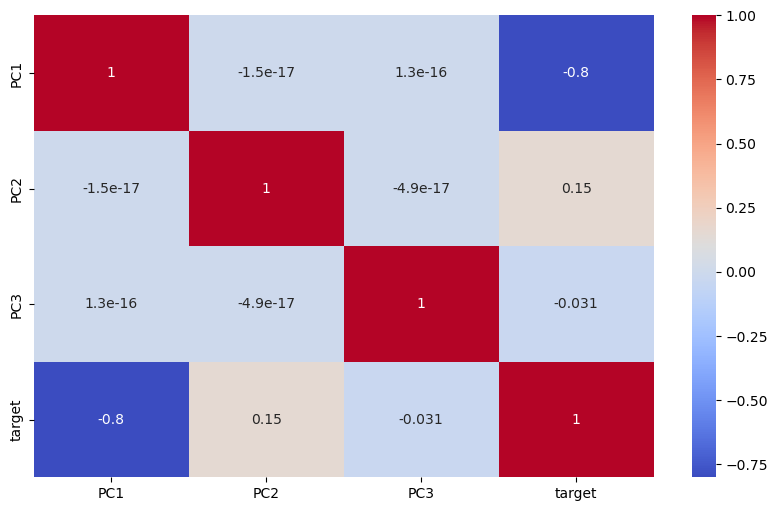

In [14]:
# TASK -5 Compute the correlations between the 3 PCs and the target, 
# then compare them to the task 3 values and select a final feature set

X_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2', 'PC3']
)
X_df['target'] = ecg_clean[140].values
print(X_df.head())
print(X_df.shape)

corr = X_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True, cmap='coolwarm')

## 5. Feature Selection
##### Justification for using PCs:
- PC1 has stronger correlation with target(-0.8) than any individual raw feature
- PCs have zero multicollinearity unlike ABT features
- Together they retain 83.7% of variance
##### - This makes them a cleaner, more reliable input for Decision Tree and Random forest

In [15]:
# TASK -6 subset A gets the first 1557.6, the last 1038.4 should be in subset B

subset_a = X_df.iloc[:1558, :]
subset_b = X_df.iloc[1558:, :]
print(subset_a['target'].value_counts())
print(subset_b['target'].value_counts())

target
1.0    1084
0.0     474
Name: count, dtype: int64
target
1.0    741
0.0    297
Name: count, dtype: int64


## 6. Data Partitioning
- Subset A: 1558 rows, 1084 normal vs 474 abnormal(2.29:1)
- Subset B: 1038 rows, 741 normal vs 297 abnormal(2.49:1)
- Both subsets reasonably reflect full dataset distribution(2.4:1)
- Subset B has slightly higher proportion of normal heartbeats which could inflate model accuracy and make evaluation overly optimistic

Best parameters found:  {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Best cross-validation score:  0.9619516515354654
Best estimator found:  DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
Test Set Accuracy (Grid Search): 0.9614643545279383
Test Set F1 Score (Grid Search): 0.973404255319149


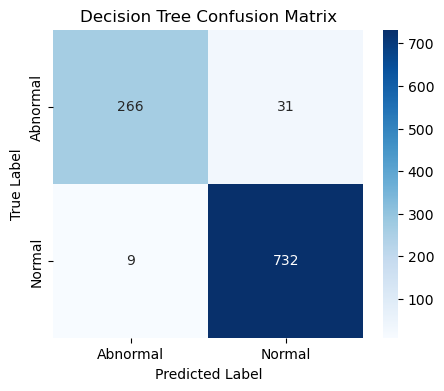

In [16]:
# TASK -7
# split data into training and testing sets
X_train = subset_a[['PC1', 'PC2', 'PC3']]
y_train = subset_a['target']
X_test = subset_b[['PC1', 'PC2', 'PC3']]
y_test = subset_b['target']

# Define the parameter grid
param_grid = {
    'min_samples_split': [2, 5, 10, 20],
    'max_depth': [3, 5, 7, 10, None],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state = 42)
# Define the GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='f1')

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters and score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)


# train the best model on X_train and predict on X_test
best_model = grid_search.best_estimator_
print("Best estimator found: ", best_model)
y_pred = best_model.predict(X_test)
print("Test Set Accuracy (Grid Search):", accuracy_score(y_test, y_pred))
print("Test Set F1 Score (Grid Search):", f1_score(y_test, y_pred))

# plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Abnormal', 'Normal'], yticklabels=['Abnormal', 'Normal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree Confusion Matrix')
plt.show()

## 7. Decision Tree Classifier
##### Hyperparameters a Decision tree has that can tune overfitting:
- max_features, max_depth, min_samples_split, min_samples_leaf and ctiterion
##### gridsearchcv showed the best hyperparameters using 5-fold cross validation on the training set:
- entropy: tree uses information gain to decide split rather than gini,
- max_depth: 5, the tree can grow at most 5 levels deep which prevents overfitting
- min_samples_split: 2, a node will split as long as it has at least 2 samples
- CV score: 0.96, 96% F1 on training folds
##### predicting on the X_test showed:
- 31 use cases predicted as normal but actually abnormal, that means those are actually false negatives from an industrial
- the model missed 9 real abnormal time-series signals
##### the test score is slightly higher thsn the training score, showing:
- it is a well balanced model
- if the model was overfitting, trainig score would be higher than test score
- if underfiting both scores would be low
- but both scores here are close to each other
##### this is due to gridsearchcv max_depth which prevented the tree from growing too deep and memorising the trainig data

In [17]:
# TASK -8
# Define the parameter grid
param_grid = {
    'min_samples_split': [2, 5, 10, 20],
    'max_depth': [3, 5, 7, 10, None],
    'criterion': ['gini', 'entropy'],
    'n_estimators': [50, 100, 200]
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
# Define the GridSearchCV
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='f1')

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters and score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)


# train the best model on X_train and predict on X_test
best_model = grid_search.best_estimator_
print("Best estimator found: ", best_model)
y_pred = best_model.predict(X_test)
print("Test Set Accuracy (Grid Search):", accuracy_score(y_test, y_pred))
print("Test Set F1 Score (Grid Search):", f1_score(y_test, y_pred))




Best parameters found:  {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score:  0.9691242027387836
Best estimator found:  RandomForestClassifier(criterion='entropy', random_state=42)
Test Set Accuracy (Grid Search): 0.9576107899807321
Test Set F1 Score (Grid Search): 0.9706275033377837


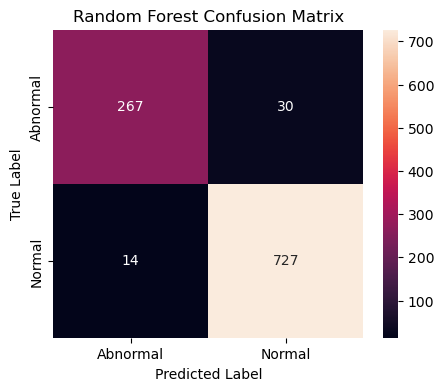

In [18]:
# plotting the random forest confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Abnormal', 'Normal'], yticklabels=['Abnormal', 'Normal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

#highlight at least one false positive or false negative test instance 
y_test_arr = np.asarray(y_test)
misclassified = np.where(y_test_arr != best_model.predict(X_test))
#print(misclassified)

# running one index to see its PC values and true label
#print(X_test.iloc[70])
#print("True labe:", y_test.iloc[70])
#print("Predicted:", best_model.predict(X_test.iloc[[70]]))

## 8. Random Forest Classifier
best parameters found: entropy, max_depth=None(trees grow without depth limit, does not cause overfitting in randomforest bc of averaging), min_samples_split=2, n_estimators = 100 and justification
#### predicting on the X_test showed:
•	14 use cases predicted as normal but actually abnormal, that means those are actually false negatives from a clinical perpectve
•	the model missed 30 real abnormal heartbeats
#### the test score is slightly higher thsn the training score, showing:
•	it is a well balanced model
•	if the model was overfitting, trainig score would be higher than test score
•	if underfiting both scores would be low
•	but both scores here are close to each other

-	false negative instances at index 1628, PC1:0.275, PC2:-2.87, PC3:-1.40, True label abnormal (0), Predicted label (1), the extreme PC2 value likely confused the model into misclassifying it as normal. 
-	decision tree misses fewer abnormal time-series signals (9 vs 14), making it safer in this context despite random forest having lightly better  F1 score

   

## 9. Model Comparison
- Decision tree F1 0.973 marginally outperforms random forest F1
- Decision tree has superio generalisation in this specific context
- This contradicts the Condoecet jury theorem
- Possible reason: with only 3 features, random feature sampling in random forest dilutes the influence of PC1 which is the dominant predictor at -0.8 correlation with target
- the theorem assumes each voter performs better than chance, but when strong predictors are randomly excluded, individual trees may perform worse than a single well configured tree


In [19]:
# TASK 10 ON RANDOM FOREST

X = X_df[['PC1', 'PC2', 'PC3']]
y = X_df['target'] 

# K-Fold Cross Validation
k = 10  
kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Initialize the RandomForestClassifier model using best parameters
model = RandomForestClassifier(
     min_samples_split = 2,
     max_depth = None,
     criterion = 'entropy',
     n_estimators = 100,
    random_state=42
)

# Perform Cross Validation
rf_scores = cross_val_score(model, X, y, cv=kf, scoring='f1')

print(f"Accuracy for each fold: {rf_scores}")

average_accuracy = np.mean(rf_scores) 
print(f"Average Accuracy: {average_accuracy:.2f}")

Accuracy for each fold: [0.97050938 0.97002725 0.98092643 0.97814208 0.96457766 0.98082192
 0.96256684 0.96756757 0.98360656 0.96236559]
Average Accuracy: 0.97


In [20]:
# TASK 10 ON DECISION TREE

X = X_df[['PC1', 'PC2', 'PC3']]
y = X_df['target']
print(y.value_counts())
print(X.shape)

# K-Fold Cross Validation
k = 10  
kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Initialize the RandomForestClassifier model
model = DecisionTreeClassifier(
     min_samples_split = 2 ,
     max_depth = 5,
     criterion = 'entropy', 
    random_state = 42
)

# Perform Cross Validation
dt_scores = cross_val_score(model, X, y, cv=kf, scoring='f1', error_score='raise')


print(f"Accuracy for each fold: {dt_scores}")

average_accuracy = np.mean(dt_scores) 
print(f"Average Accuracy: {average_accuracy:.2f}")

target
1.0    1825
0.0     771
Name: count, dtype: int64
(2596, 3)
Accuracy for each fold: [0.97297297 0.96986301 0.97560976 0.97814208 0.95652174 0.98351648
 0.9602122  0.9703504  0.98071625 0.95442359]
Average Accuracy: 0.97


In [21]:

# conduct the Wilcoxon-Signed Rank Test
stats.wilcoxon(dt_scores, rf_scores)

WilcoxonResult(statistic=np.float64(12.0), pvalue=np.float64(0.25))

## 10. Cross-Validation & Statistical Testing
- Average F1: both models 0.97 ovver 10 folds
- individual folds scores show some variation but similar patterns
- wilcoxon test p-value: 0.25, difference is not statistically significant
- connot conclude wither model is superior based on 10-fold CV
- contrast with previous where decision tree marginally outperformed on the single split, showing splits can be misleading which is exactly why kfold is prefered